In [2]:
# Подключение Python к базе, импорт необходимых библиотек

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

conn = sqlite3.connect(r'C:\Users\anast\OneDrive\Desktop\project\bike_project')

orders = pd.read_sql('SELECT * FROM orders', conn)
order_items = pd.read_sql('SELECT * FROM order_items', conn)
products = pd.read_sql('SELECT * FROM products', conn)
customers = pd.read_sql('SELECT * FROM customers', conn)
stores = pd.read_sql('SELECT * FROM stores', conn)
categories = pd.read_sql('SELECT * FROM categories', conn)
brands = pd.read_sql('SELECT * FROM brands', conn)

pd.options.display.float_format = '{:,.2f}'.format

In [3]:
# Расшифровка кодов статусов, вывод количества заказов по каждому статусу

status_map = {1: 'Pending', 2: 'Processing', 3: 'Rejected', 4: 'Completed'}
orders['status_name'] = orders['order_status'].map(status_map)

print(orders['status_name'].value_counts())

status_name
Completed     1445
Processing      63
Pending         62
Rejected        45
Name: count, dtype: int64


In [4]:
# Общие показатели воронки, вывод количества отклоненных и выполненных заказов

total_orders = len(orders)
rejected = (orders['status_name'] == 'Rejected').sum()
completed = (orders['status_name'] == 'Completed').sum()

rejection_rate = rejected / total_orders * 100
completion_rate = completed / total_orders * 100

print(f'Всего заказов: {total_orders}')
print(f'Отклонено: {rejected} ({rejection_rate:.1f}%)')
print(f'Выполнено: {completed} ({completion_rate:.1f}%)')

Всего заказов: 1615
Отклонено: 45 (2.8%)
Выполнено: 1445 (89.5%)


In [5]:
# Пошаговая конверсия
# стартовая точка — все заказы, первый барьер — не отклоненные заказы, второй барьер — выполненные заказы, дошедшие до конца воронки

step_all = len(orders)
step_not_rejected = (orders['status_name'] != 'Rejected').sum()
step_completed = (orders['status_name'] == 'Completed').sum()

funnel_data = pd.DataFrame({
    'stage': ['Все заказы', 'Не отклонены', 'Выполнены'],
    'count': [step_all, step_not_rejected, step_completed]
})

funnel_data['conversion_from_start'] = (funnel_data['count'] / step_all * 100).round(1)
funnel_data['conversion_from_prev'] = (
    funnel_data['count'] / funnel_data['count'].shift(1) * 100
).round(1)

print(funnel_data) # вывод конверсии относительно стартовой точки и предыдущего барьера

          stage  count  conversion_from_start  conversion_from_prev
0    Все заказы   1615                 100.00                   NaN
1  Не отклонены   1570                  97.20                 97.20
2     Выполнены   1445                  89.50                 92.00


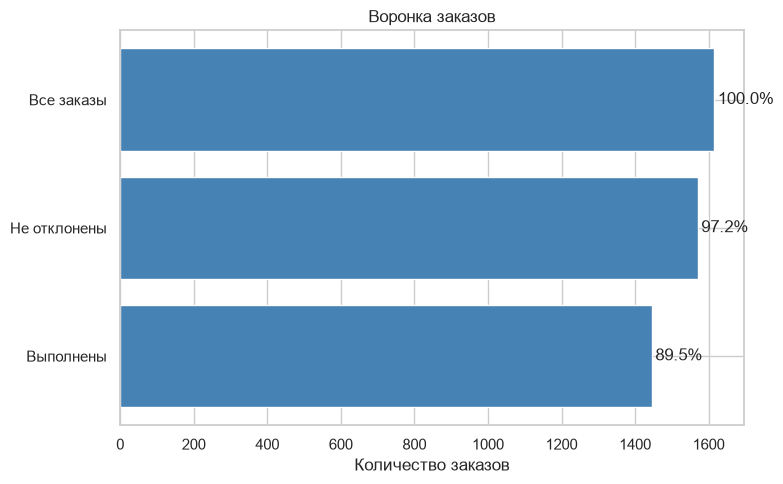

In [7]:
# Визуализация воронки (bar chart)

plt.figure(figsize=(8, 5))
bars = plt.barh(funnel_data['stage'], funnel_data['count'], color='steelblue')
plt.gca().invert_yaxis()  # чтобы "Все заказы" был сверху, а не снизу
plt.title('Воронка заказов')
plt.xlabel('Количество заказов')

for bar, pct in zip(bars, funnel_data['conversion_from_start']):
    plt.text(
        bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
        f'{pct}%', va='center'
    )

plt.tight_layout()
plt.show()

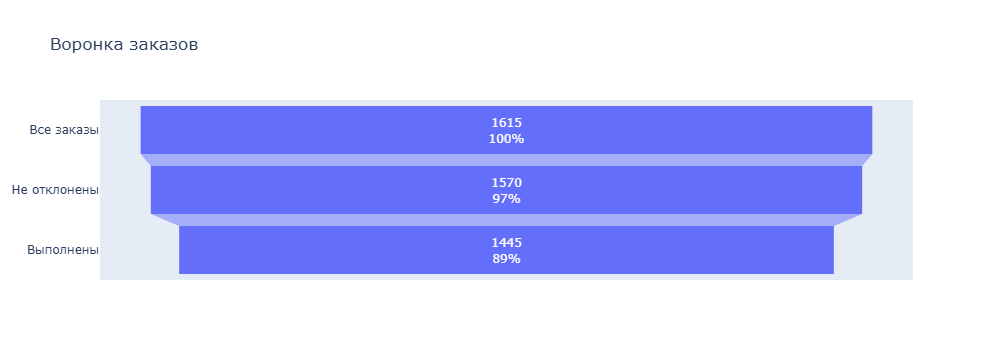

In [6]:
# Визуализация воронки (интерактивный график)

import plotly.graph_objects as go

fig = go.Figure(go.Funnel(
    y=funnel_data['stage'],
    x=funnel_data['count'],
    textinfo="value+percent initial"
))
fig.update_layout(title='Воронка заказов')
fig.show()

In [8]:
# Разбиение воронки заказов по магазинам (сводная таблица)

merged = orders.merge(stores[['store_id', 'store_name']], on='store_id')

pivot = merged.pivot_table(
    index='store_name',
    columns='status_name',
    values='order_id',
    aggfunc='count',
    fill_value=0
)

pivot = pivot[['Pending', 'Processing', 'Rejected', 'Completed']]
pivot['total'] = pivot.sum(axis=1)
pivot['rejection_rate_%'] = (pivot['Rejected'] / pivot['total'] * 100).round(1)
pivot['completion_rate_%'] = (pivot['Completed'] / pivot['total'] * 100).round(1)

print(pivot)

status_name       Pending  Processing  Rejected  Completed  total  \
store_name                                                          
Baldwin Bikes          29          31        14       1019   1093   
Rowlett Bikes           8           5        19        142    174   
Santa Cruz Bikes       25          27        12        284    348   

status_name       rejection_rate_%  completion_rate_%  
store_name                                             
Baldwin Bikes                 1.30              93.20  
Rowlett Bikes                10.90              81.60  
Santa Cruz Bikes              3.40              81.60  


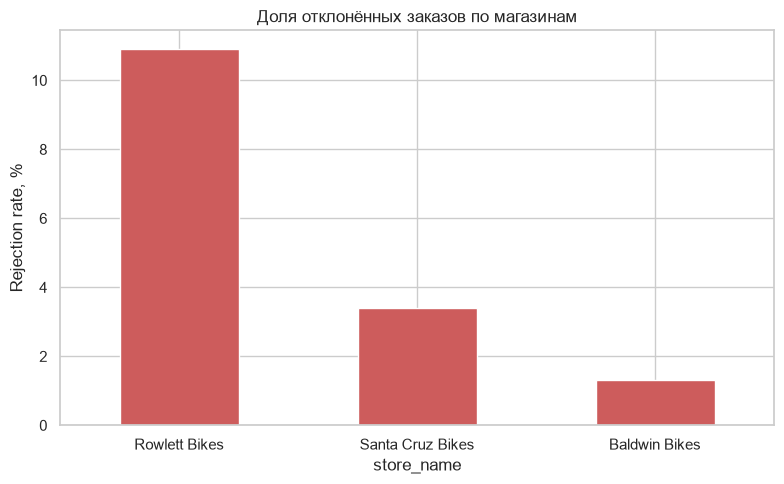

In [9]:
# Визуализация воронки по магазинам

plt.figure(figsize=(8, 5))
pivot['rejection_rate_%'].sort_values(ascending=False).plot(
    kind='bar', color='indianred'
)
plt.title('Доля отклонённых заказов по магазинам')
plt.ylabel('Rejection rate, %')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Основные выводы и наблюдения

- Общая конверсия из "заказ создан" в "заказ выполнен" — 89.5%, отклонено всего 2.8% заказов
- Наблюдается значительный разброс rejection rate (процента отклоненных заказов) между магазинами: у магазина Rowlett Bikes — 10.9%, при этом у магазина Baldwin Bikes — всего 1.3% (почти в 4 раза меньше)
- Rowlett Bikes — самый маленький магазин по объёму заказов (174 заказа против 1093 у Baldwin), но именно у него хуже всего показатель отказов — стоит разобраться в причине отдельно, проведя дополнительный анализ. Проблема может быть с ассортиментом/логистикой/ обработкой заказов в конкретном магазине)